In [5]:
%load_ext memory_profiler

Generowanie chmury 250 punktów dla 4-torusa...
Obliczanie kompleksu Ripsa (to potrwa chwilę dla maxdim=3)...


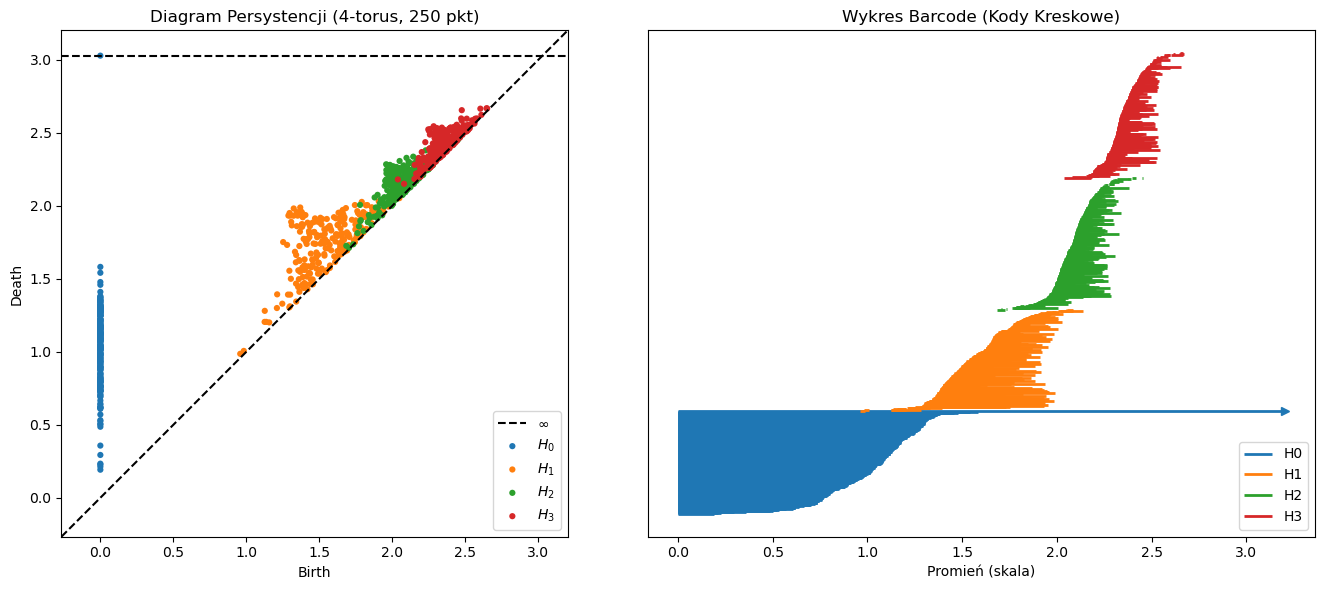

peak memory: 12194.26 MiB, increment: 9549.89 MiB


In [ ]:
%%memit
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

def generate_torus_points(n, num_points):
    angles = np.random.uniform(0, 2 * np.pi, (num_points, n))
    points = np.zeros((num_points, 2 * n))
    for i in range(n):
        points[:, 2*i] = np.cos(angles[:, i])
        points[:, 2*i+1] = np.sin(angles[:, i])
    return points

# --- REPRODUKCJA TWOJEGO SCENARIUSZA ---
n = 4
num_points = 250

print(f"Generowanie chmury {num_points} punktów dla {n}-torusa...")
points = generate_torus_points(n, num_points)

print("Obliczanie kompleksu Ripsa (to potrwa chwilę dla maxdim=3)...")
# Używamy ciała Z_2 (wystarczy do wizualizacji) i liczymy do wymiaru 3 włącznie
res = ripser(points, maxdim=3, coeff=2)
dgms = res['dgms']

# --- RYSOWANIE WYKRESÓW ---
fig = plt.figure(figsize=(14, 6))

# 1. Diagram Persystencji (narzędzie wbudowane w persim)
ax1 = fig.add_subplot(1, 2, 1)
plot_diagrams(dgms, show=False, ax=ax1)
ax1.set_title(f"Diagram Persystencji ({n}-torus, {num_points} pkt)")

# 2. Wykres Barcode (rysowany manualnie dla lepszej kontroli)
ax2 = fig.add_subplot(1, 2, 2)

# Kolory odpowiadające wymiarom H0, H1, H2, H3
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels_added = set()

# Zmienna pomocnicza do rozmieszczania linii na osi Y
y_offset = 0 

# Szukamy maksymalnej wartości 'death', żeby wiedzieć, gdzie uciąć nieskończoność
max_death = max([d for dgm in dgms for b, d in dgm if d != float('inf')] + [0])
infinity_cap = max_death * 1.2

for dim, dgm in enumerate(dgms):
    # Sortujemy cechy po czasie narodzin, żeby wykres był czytelniejszy
    dgm_sorted = sorted(dgm, key=lambda x: x[0])
    
    for birth, death in dgm_sorted:
        # Obsługa cech o nieskończonym czasie życia (globalnych)
        is_infinite = False
        if death == float('inf'):
            death = infinity_cap
            is_infinite = True
            
        label = f"H{dim}" if dim not in labels_added else ""
        labels_added.add(dim)
        
        # Rysowanie pojedynczej kreski
        ax2.hlines(y=y_offset, xmin=birth, xmax=death, 
                   colors=colors[dim], linewidth=2, label=label)
        
        # Jeśli cecha żyje w nieskończoność, dodajemy strzałkę na końcu
        if is_infinite:
            ax2.plot(death, y_offset, marker='>', color=colors[dim], markersize=6)
            
        y_offset += 1

ax2.set_title("Wykres Barcode (Kody Kreskowe)")
ax2.set_xlabel("Promień (skala)")
ax2.set_yticks([]) # Ukrywamy wartości na osi Y, liczy się tylko długość kresek
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

Wczytywanie logów z pliku ripser/ripser_log.txt...
Dane sparsowane pomyślnie. Generowanie wykresów...


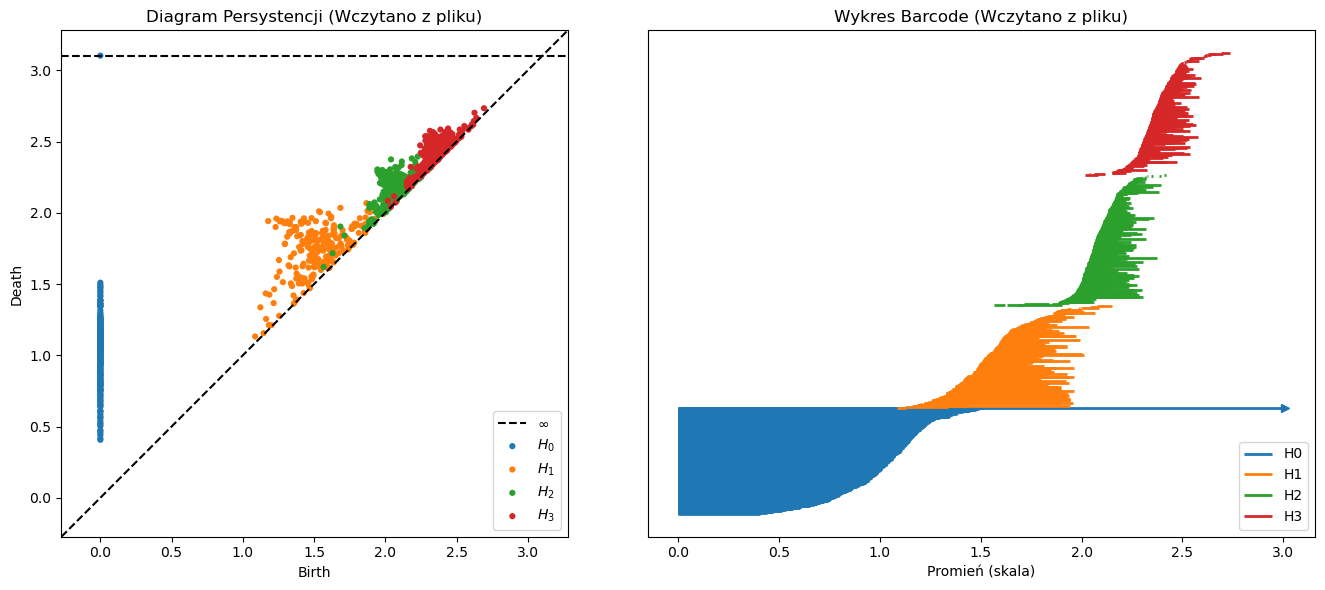

In [9]:
# Ripser Check 
import matplotlib.pyplot as plt
from persim import plot_diagrams
import numpy as np
import os

# --- 1. ODCZYT Z PLIKU ---
file_path = "ripser/ripser_log.txt"

dgms_dict = {0: []}
current_dim = 0

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Nie znaleziono pliku {file_path}. Uruchom najpierw kod w terminalu z operatorem '>'.")

print(f"Wczytywanie logów z pliku {file_path}...")

with open(file_path, "r") as file:
    for line in file:
        line = line.strip()
        
        # Ignorujemy puste linie oraz ewentualne śmieci z profilera 
        # (na wypadek gdyby trafiły do pliku)
        if not line or line.startswith(('Command', 'User', 'System', 'Percent', 'Elapsed', 'Maximum', 'Average', 'Major', 'Minor', 'Voluntary', 'Involuntary', 'Swaps', 'File', 'Socket', 'Signals', 'Page', 'Exit')):
            continue
            
        if line.startswith('persistence intervals in dim'):
            current_dim = int(line.split()[-1].replace(':', ''))
            dgms_dict[current_dim] = []
            
        elif line.startswith('['):
            parts = line[1:-1].split(',')
            birth = float(parts[0].strip())
            death_str = parts[1].strip()
            
            if death_str == '':
                death = float('inf')
            else:
                death = float(death_str)
                
            dgms_dict[current_dim].append((birth, death))

# Przygotowanie danych dla persim
max_dim = max(dgms_dict.keys())
dgms = [np.array(dgms_dict.get(i, [])) for i in range(max_dim + 1)]
print("Dane sparsowane pomyślnie. Generowanie wykresów...")

# --- 2. RYSOWANIE WYKRESÓW ---
fig = plt.figure(figsize=(14, 6))

# Diagram Persystencji
ax1 = fig.add_subplot(1, 2, 1)
plot_diagrams(dgms, show=False, ax=ax1)
ax1.set_title("Diagram Persystencji (Wczytano z pliku)")

# Wykres Barcode
ax2 = fig.add_subplot(1, 2, 2)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels_added = set()
y_offset = 0 

# Ustalenie limitu dla nieskończoności
max_death = max([d for dgm in dgms for b, d in dgm if d != float('inf')] + [0])
infinity_cap = max_death * 1.1

for dim, dgm in enumerate(dgms):
    if len(dgm) == 0: continue
    
    # Sortowanie po narodzinach dla lepszej czytelności
    dgm_sorted = sorted(dgm, key=lambda x: x[0])
    
    for birth, death in dgm_sorted:
        is_infinite = False
        if death == float('inf'):
            death = infinity_cap
            is_infinite = True
            
        label = f"H{dim}" if dim not in labels_added else ""
        labels_added.add(dim)
        
        ax2.hlines(y=y_offset, xmin=birth, xmax=death, 
                   colors=colors[dim], linewidth=2, label=label)
        if is_infinite:
            ax2.plot(death, y_offset, marker='>', color=colors[dim], markersize=6)
            
        y_offset += 1

ax2.set_title("Wykres Barcode (Wczytano z pliku)")
ax2.set_xlabel("Promień (skala)")
ax2.set_yticks([]) 
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [7]:
%%memit
import numpy as np
import pandas as pd
from ripser import ripser

def count_betti_numbers(dgms, threshold=0.5):
    """Odfiltrowuje szum - zostawia cechy o czasie życia > threshold."""
    betti = []
    for dim, dgm in enumerate(dgms):
        if len(dgm) == 0:
            betti.append(0)
            continue
            
        count = 0
        for birth, death in dgm:
            if death == float('inf') or (death - birth) > threshold:
                count += 1
        betti.append(count)
    return betti

def takens_embedding(series, delay, dimension):
    """
    Tworzy zanurzenie Takensa (time-delay embedding) dla szeregu czasowego 1D.
    """
    N = len(series)
    if N - (dimension - 1) * delay <= 0:
        raise ValueError("Szereg czasowy jest za krótki dla takiego wymiaru/opóźnienia.")
    
    # Tworzenie macierzy, gdzie każda kolumna to przesunięty szereg
    embedded = np.array([series[i : i + (dimension - 1) * delay + 1 : delay] 
                         for i in range(N - (dimension - 1) * delay)])
    return embedded

# --- PARAMETRY SYGNAŁU I ZANURZENIA ---
# Generujemy 4 pełne okresy sinusoidy
points_per_period = 100
t = np.linspace(0, 4 * 2 * np.pi, 4 * points_per_period)
sine_wave = np.sin(t)

# Opóźnienie (delay) ustawiamy na 1/4 okresu (25 próbek)
tau = int(points_per_period / 4) 

dimensions = [1, 2, 3, 4, 5]
results = {}

print("Obliczanie kompleksu Ripsa dla różnych wymiarów zanurzenia...")

for n in dimensions:
    # 1. Tworzymy chmurę punktów w n-wymiarach za pomocą Takensa
    embedded_points = takens_embedding(sine_wave, delay=tau, dimension=n)
    
    # 2. Liczymy homologie. maxdim=2 wystarczy, wyżej dla okręgu i tak będą zera, 
    # a oszczędzi to pamięć RAM dla n=5.
    res = ripser(embedded_points, maxdim=2)
    
    # 3. Zliczamy liczby Bettiego
    # Dla sinusoidy próg 0.5 jest bardzo bezpieczny (rozmiar pętli to ok. 2.0)
    betti_counts = count_betti_numbers(res['dgms'], threshold=0.5)
    
    # Uzupełnienie zerami do H_2 dla równej tabeli
    while len(betti_counts) <= 2:
        betti_counts.append(0)
        
    results[f'Zanurzenie w R^{n}'] = betti_counts

# --- TWORZENIE TABELI PORÓWNAWCZEJ ---
df = pd.DataFrame(results, index=['H_0 (Spójne składowe)', 'H_1 (Pętle 1D)', 'H_2 (Pustki 2D)'])

print("\n--- PORÓWNANIE GRUP HOMOLOGII DLA SINUSOIDY ---")
print(df)

Obliczanie kompleksu Ripsa dla różnych wymiarów zanurzenia...

--- PORÓWNANIE GRUP HOMOLOGII DLA SINUSOIDY ---
                       Zanurzenie w R^1  Zanurzenie w R^2  Zanurzenie w R^3  \
H_0 (Spójne składowe)                 1                 1                 1   
H_1 (Pętle 1D)                        0                 1                 1   
H_2 (Pustki 2D)                       0                 0                 0   

                       Zanurzenie w R^4  Zanurzenie w R^5  
H_0 (Spójne składowe)                 1                 1  
H_1 (Pętle 1D)                        1                 1  
H_2 (Pustki 2D)                       0                 0  
peak memory: 7219.85 MiB, increment: 1.12 MiB
